# 02 · Proxy Validation and Lag Screening
**Goal:** Rank candidate environmental regressors for `absinc` (absolute inclination) using
correlation analysis, Engle–Granger cointegration testing, and lagged cross-correlation screening.
Output: a validated feature matrix of ranked and lagged predictors for the imputation benchmark.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_PATH   = "data/interim/aligned/st02_aligned_dataset.csv"
OUTPUT_PATH = "data/processed/feature_matrix.parquet"
FIG_PATH    = "outputs/figures/"

# ── Config ────────────────────────────────────────────────────────────────────
TARGET      = "absinc"
MAX_LAG_H   = 72          # maximum lag to screen (hours); 72h = 3 days thermal memory
LAG_STEP    = 1           # step in hours
COINT_ALPHA = 0.05        # significance level for cointegration tests

In [29]:
df = pd.read_csv(DATA_PATH)
df.index = pd.to_datetime(df.datetime)

# Drop non-proxy columns
EXCLUDE  = ["charge", "datetime", "temp", "hum", "oikolab_wind_speed (m/s)", "oikolab_wind_direction (deg)", "oikolab_total_cloud_cover (0-1)",   TARGET]
proxies  = [c for c in df.columns if c not in EXCLUDE]

print(f"Loaded: {df.shape[0]} rows | {df.index[0]} → {df.index[-1]}")
print(f"Target : {TARGET}")
print(f"Proxies: {proxies}")
df[[TARGET] + proxies].describe().T

Loaded: 57278 rows | 2018-07-25 23:00:00 → 2025-02-05 12:00:00
Target : absinc
Proxies: ['oikolab_temperature (degC)', 'oikolab_dewpoint_temperature (degC)', 'oikolab_relative_humidity (0-1)', 'oikolab_wetbulb_temperature (degC)', 'oikolab_skin_temperature (degC)', 'oikolab_urban_temperature (degC)', 'oikolab_total_precipitation (mm of water equivalent)', 'oikolab_surface_solar_radiation (W/m^2)', 'oikolab_surface_thermal_radiation (W/m^2)']


,count,mean,std,min,25%,50%,75%,max
absinc,39775.0,114.146001,52.153965,-53.45,84.8125,110.975,155.220833,231.80
oikolab_temperature (degC),57278.0,13.619411,7.938618,-9.98,7.6100,12.860,19.330000,36.11
oikolab_dewpoint_temperature (degC),57278.0,8.402467,6.144757,-14.63,4.1400,8.750,13.390000,22.10
oikolab_relative_humidity (0-1),57278.0,0.735117,0.174166,0.18,0.6100,0.770,0.880000,1.00
oikolab_wetbulb_temperature (degC),57278.0,10.452150,6.327203,-10.76,5.7000,10.380,15.710000,24.43
oikolab_skin_temperature (degC),57278.0,13.464605,9.299911,-15.45,6.5300,12.520,19.530000,42.21
oikolab_urban_temperature (degC),57278.0,14.425468,7.942013,-7.32,8.1500,13.560,20.750000,34.50
oikolab_total_precipitation (mm of water equivalent),57278.0,0.104979,0.365236,0.00,0.0000,0.000,0.030000,8.45
oikolab_surface_solar_radiation (W/m^2),57278.0,171.345266,247.406748,0.00,0.0000,6.240,296.747500,945.36
oikolab_surface_thermal_radiation (W/m^2),57278.0,318.925681,43.050782,198.22,288.4500,323.140,351.730000,431.26


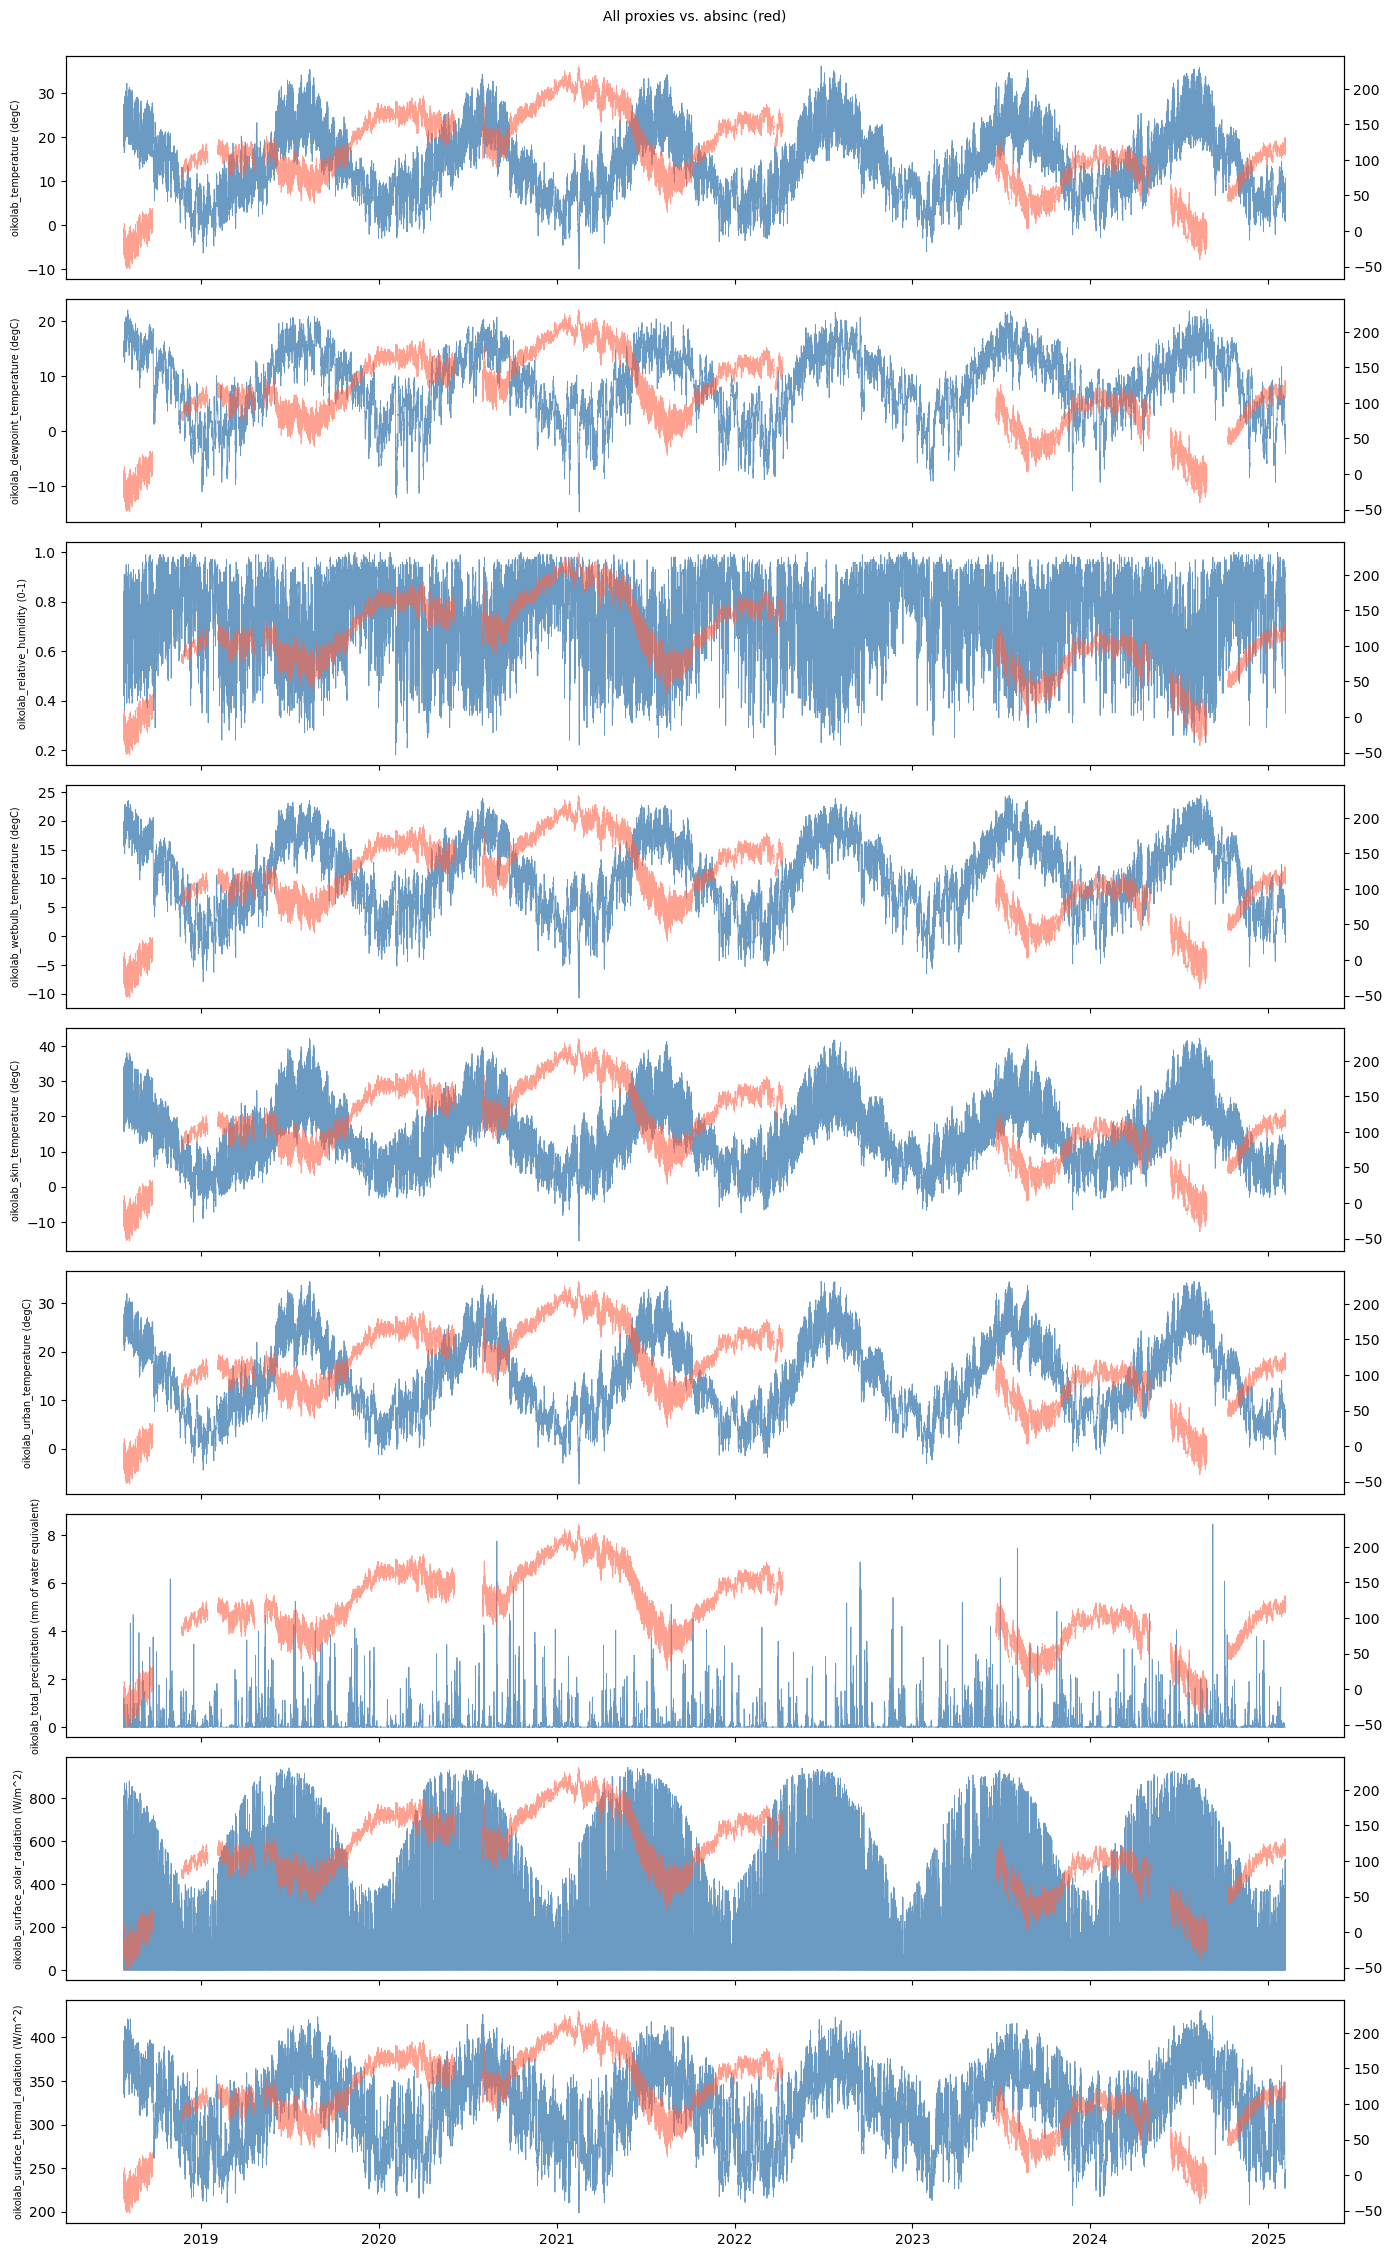

In [30]:
fig, axes = plt.subplots(len(proxies), 1, figsize=(14, 2.5 * len(proxies)), sharex=True)
for ax, col in zip(axes, proxies):
    ax.plot(df.index, df[col], lw=0.6, color="steelblue", alpha=0.8)
    ax2 = ax.twinx()
    ax2.plot(df.index, df[TARGET], lw=0.6, color="tomato", alpha=0.6)
    ax.set_ylabel(col, fontsize=7)
plt.suptitle("All proxies vs. absinc (red)", y=1.001, fontsize=10)
plt.tight_layout()
plt.savefig(f"{FIG_PATH}02_proxy_overview.png", dpi=150, bbox_inches="tight")
plt.show()

In [31]:
# ── Proxy Ranking Final Summary Table ─────────────────────────────────────────
from statsmodels.tsa.ardl import ARDL
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import adfuller
from scipy.stats import pearsonr
from scipy import stats

# ── Reference period ──────────────────────────────────────────────────────────
# Defined as the longest pre-gap segment free from obvious anomalous episodes.
# Adjust dates after visual inspection of Cell 3 (proxy overview plot).
REF_START = "2019-01-01"
REF_END   = "2022-03-01"

ref = df.loc[REF_START:REF_END].dropna(subset=[TARGET])

print(f"Full dataset     : {df.shape[0]} rows | {df.index[0].date()} → {df.index[-1].date()}")
print(f"Reference period : {ref.shape[0]} rows | {ref.index[0].date()} → {ref.index[-1].date()}")
print(f"Missing in target (full) : {df[TARGET].isna().sum()} rows "
      f"({100 * df[TARGET].isna().sum() / len(df):.1f}%)")
print(f"Missing in target (ref)  : {ref[TARGET].isna().sum()} rows\n")

# ── 1. ADF test ────────────────────────────────────────────────────────────────
def adf_summary(series, name):
    result = adfuller(series.dropna(), autolag="AIC")
    return {
        "proxy":        name,
        "ADF_stat":     round(result[0], 4),
        "ADF_pvalue":   round(result[1], 4),
        "I1_candidate": result[1] > 0.05,
    }

# ── 2. ARDL Bounds F-test ──────────────────────────────────────────────────────
def bounds_f(target_series, proxy_series):
    clean = pd.concat([target_series, proxy_series], axis=1).dropna()
    if len(clean) < 50:
        return None, None, "INSUFFICIENT DATA"
    col     = clean.columns[1]
    res_unr = ARDL(clean.iloc[:, 0], lags=1,
                   exog=clean[[col]],
                   order={col: 1}).fit()
    res_r   = AutoReg(clean.iloc[:, 0].values, lags=1).fit()
    n, k    = len(clean), len(res_unr.params)
    rss_r   = res_r.resid.var()   * (n - 2)
    rss_unr = res_unr.resid.var() * (n - k)
    q       = 2
    F       = ((rss_r - rss_unr) / q) / (rss_unr / (n - k))
    p       = 1 - stats.f.cdf(F, q, n - k)
    confirmed = "YES" if F > 5.15 else "INCONCLUSIVE" if F > 4.68 else "NO"
    return round(F, 2), round(p, 4), confirmed

# ── 3. Optimal lag + max |Pearson r| ──────────────────────────────────────────
def lag_screening(target_series, proxy_series, max_lag=72):
    best_r, best_lag = 0, 0
    for lag in range(0, max_lag + 1):
        shifted = proxy_series.shift(lag)
        valid   = pd.concat([target_series, shifted], axis=1).dropna()
        if len(valid) < 30:
            continue
        r, _ = pearsonr(valid.iloc[:, 0], valid.iloc[:, 1])
        if abs(r) > abs(best_r):
            best_r, best_lag = r, lag
    return round(best_r, 4), best_lag

# ── 4. ADF on target first — report integration order ─────────────────────────
target_adf = adf_summary(ref[TARGET], TARGET)
print(f"ADF on target ({TARGET}):")
print(f"  stat={target_adf['ADF_stat']}  p={target_adf['ADF_pvalue']}  "
      f"I(1)={'YES' if target_adf['I1_candidate'] else 'NO'}\n")

# ── 5. Run all three tests for every proxy ────────────────────────────────────
rows = []
for col in proxies:
    adf              = adf_summary(ref[col], col)
    F, p, confirmed  = bounds_f(ref[TARGET], ref[col])
    best_r, best_lag = lag_screening(ref[TARGET], ref[col])

    rows.append({
        "proxy":                    col,
        "ADF_stat":                 adf["ADF_stat"],
        "ADF_pvalue":               adf["ADF_pvalue"],
        "proxy_I1":                 "YES" if adf["I1_candidate"] else "NO",
        "bounds_F":                 F,
        "bounds_p":                 p,
        "long_run_confirmed":       confirmed,
        "optimal_lag_h":            best_lag,
        "max_abs_pearson_r":        abs(best_r),
        "pearson_sign":             "negative" if best_r < 0 else "positive",
        "operationally_available":  col != "temp",
    })

# ── 6. Sort: available first, then by |r| ─────────────────────────────────────
ranking_df = pd.DataFrame(rows)
ranking_df = ranking_df.sort_values(
    ["operationally_available", "max_abs_pearson_r"],
    ascending=[False, False]
).reset_index(drop=True)

# ── 7. Assign selection tier ──────────────────────────────────────────────────
def assign_tier(row):
    if not row["operationally_available"]:
        return "reference only"
    if row["long_run_confirmed"] != "YES":
        return "excluded"
    if row.name == 0:
        return "PRIMARY"
    if row["max_abs_pearson_r"] >= 0.60:
        return "secondary"
    if row["max_abs_pearson_r"] >= 0.40:
        return "tertiary"
    return "excluded"

ranking_df["selection_tier"] = ranking_df.apply(assign_tier, axis=1)

# ── 8. Save full table ────────────────────────────────────────────────────────
ranking_df.to_csv("outputs/tables/02_proxy_ranking_final.csv", index=False)

# ── 9. Print selection summary ────────────────────────────────────────────────
primary = ranking_df[ranking_df["selection_tier"] == "PRIMARY"]["proxy"].values[0]
opt_lag = ranking_df[ranking_df["selection_tier"] == "PRIMARY"]["optimal_lag_h"].values[0]
max_r   = ranking_df[ranking_df["selection_tier"] == "PRIMARY"]["max_abs_pearson_r"].values[0]

print(f"Reference period : {REF_START} → {REF_END}")
print(f"Lag screening    : 0–72 hours")
print(f"Target I(1)      : {'YES' if target_adf['I1_candidate'] else 'NO'}")
print(f"\n→ PRIMARY proxy  : {primary}")
print(f"  optimal lag    : {opt_lag} h")
print(f"  max |r|        : {max_r}\n")

# ── 10. Display condensed ranking table ───────────────────────────────────────
ranking_df[[
    "proxy", "proxy_I1", "long_run_confirmed",
    "optimal_lag_h", "max_abs_pearson_r", "pearson_sign",
    "operationally_available", "selection_tier"
]]

Full dataset     : 57278 rows | 2018-07-25 → 2025-02-05
Reference period : 24997 rows | 2019-01-01 → 2022-03-01
Missing in target (full) : 17503 rows (30.6%)
Missing in target (ref)  : 0 rows

ADF on target (absinc):
  stat=-2.0559  p=0.2626  I(1)=YES

Reference period : 2019-01-01 → 2022-03-01
Lag screening    : 0–72 hours
Target I(1)      : YES

→ PRIMARY proxy  : oikolab_urban_temperature (degC)
  optimal lag    : 0 h
  max |r|        : 0.6829



,proxy,proxy_I1,long_run_confirmed,optimal_lag_h,max_abs_pearson_r,pearson_sign,operationally_available,selection_tier
0,oikolab_urban_temperature (degC),NO,YES,0,0.6829,negative,True,PRIMARY
1,oikolab_temperature (degC),NO,YES,0,0.6804,negative,True,secondary
2,oikolab_wetbulb_temperature (degC),NO,YES,0,0.6658,negative,True,secondary
3,oikolab_skin_temperature (degC),NO,YES,1,0.6653,negative,True,secondary
4,oikolab_dewpoint_temperature (degC),NO,YES,0,0.5924,negative,True,tertiary
5,oikolab_surface_thermal_radiation (W/m^2),NO,YES,0,0.5401,negative,True,tertiary
6,oikolab_relative_humidity (0-1),NO,YES,0,0.3377,positive,True,excluded
7,oikolab_surface_solar_radiation (W/m^2),NO,YES,2,0.3160,negative,True,excluded
8,oikolab_total_precipitation (mm of water equiv...,NO,YES,37,0.0474,positive,True,excluded


In [14]:
# ── Reference baseline period ─────────────────────────────────────────────────
# Defined after visual inspection of Cell 3.
# Use the longest pre-gap segment free from obvious anomalous episodes.

REF_START = "2019-01-01"
REF_END   = "2022-03-01"   # adjust after inspecting the plot above

ref = df.loc[REF_START:REF_END].dropna(subset=[TARGET])

print(f"Reference period : {ref.index[0].date()} → {ref.index[-1].date()}")
print(f"Rows             : {ref.shape[0]}")
print(f"Missing in target: {ref[TARGET].isna().sum()}")

Reference period : 2019-01-01 → 2022-03-01
Rows             : 24997
Missing in target: 0


In [15]:
# ADF test on levels — run on the clean reference period only
def adf_summary(series, name):
    result = adfuller(series.dropna(), autolag="AIC")
    return {"variable": name, "ADF_stat": round(result[0], 4),
            "p_value": round(result[1], 4), "lags_used": result[2],
            "I(1)_candidate": result[1] > 0.05}

adf_rows = [adf_summary(ref[TARGET], TARGET)]   # ref, not df
for col in proxies:
    adf_rows.append(adf_summary(ref[col], col))  # ref, not df

adf_df = pd.DataFrame(adf_rows).set_index("variable")
adf_df.to_csv("outputs/tables/02_adf_levels.csv")
adf_df.style.background_gradient(subset=["p_value"], cmap="RdYlGn_r")

,ADF_stat,p_value,lags_used,I(1)_candidate
variable,,,,
absinc,-2.055900,0.262600,48,True
temp,-4.354200,0.000400,48,False
hum,-10.063600,0.000000,48,False
oikolab_temperature (degC),-4.983700,0.000000,48,False
oikolab_dewpoint_temperature (degC),-7.047300,0.000000,48,False
oikolab_relative_humidity (0-1),-12.183500,0.000000,48,False
oikolab_wetbulb_temperature (degC),-5.734400,0.000000,48,False
oikolab_skin_temperature (degC),-4.205100,0.000600,48,False
oikolab_urban_temperature (degC),-4.641900,0.000100,48,False


In [21]:
from statsmodels.tsa.ardl import ARDL
from statsmodels.tsa.ar_model import AutoReg
from scipy import stats

proxy_col = "oikolab_skin_temperature (degC)"
clean = ref[[TARGET, proxy_col]].dropna()

# Unrestricted ARDL(1,1)
res_unr = ARDL(clean[TARGET], lags=1,
               exog=clean[[proxy_col]],
               order={proxy_col: 1}).fit()

# Restricted AR(1) only
res_r = AutoReg(clean[TARGET].values, lags=1).fit()

n   = len(clean)
k   = len(res_unr.params)
rss_r   = res_r.resid.var() * (n - 2)
rss_unr = res_unr.resid.var() * (n - k)
q   = 2
F   = ((rss_r - rss_unr) / q) / (rss_unr / (n - k))
p   = 1 - stats.f.cdf(F, q, n - k)

print(f"Bounds F-statistic : {F:.4f}")
print(f"p-value            : {p:.4f}")
print(f"\nPesaran (2001) critical values — case 3, k=1:")
print(f"  10%  I(0)=4.05  I(1)=4.49")
print(f"   5%  I(0)=4.68  I(1)=5.15")
print(f"   1%  I(0)=6.84  I(1)=7.84")
print(f"\nResult: F={F:.2f} → {'CONFIRMED' if F > 5.15 else 'INCONCLUSIVE' if F > 4.68 else 'NOT CONFIRMED'} at 5%")

Bounds F-statistic : 4991.5036
p-value            : 0.0000

Pesaran (2001) critical values — case 3, k=1:
  10%  I(0)=4.05  I(1)=4.49
   5%  I(0)=4.68  I(1)=5.15
   1%  I(0)=6.84  I(1)=7.84

Result: F=4991.50 → CONFIRMED at 5%


In [20]:
bt = result.bounds_test(case=3)
print(bt)

AttributeError: 'ARDLResults' object has no attribute 'bounds_test'

In [22]:
thermal_proxies = [
    "oikolab_skin_temperature (degC)",
    "oikolab_temperature (degC)",
    "oikolab_wetbulb_temperature (degC)",
    "oikolab_urban_temperature (degC)",
    "oikolab_dewpoint_temperature (degC)",
    "temp",
    "oikolab_surface_solar_radiation (W/m^2)",
    "oikolab_surface_thermal_radiation (W/m^2)",
]

bounds_rows = []
for proxy_col in thermal_proxies:
    clean = ref[[TARGET, proxy_col]].dropna()
    res_unr = ARDL(clean[TARGET], lags=1,
                   exog=clean[[proxy_col]],
                   order={proxy_col: 1}).fit()
    res_r = AutoReg(clean[TARGET].values, lags=1).fit()
    n = len(clean)
    k = len(res_unr.params)
    rss_r   = res_r.resid.var() * (n - 2)
    rss_unr = res_unr.resid.var() * (n - k)
    q = 2
    F = ((rss_r - rss_unr) / q) / (rss_unr / (n - k))
    p = 1 - stats.f.cdf(F, q, n - k)
    bounds_rows.append({
        "proxy": proxy_col,
        "F_statistic": round(F, 2),
        "p_value": round(p, 4),
        "conclusion_5pct": "CONFIRMED" if F > 5.15 else "INCONCLUSIVE" if F > 4.68 else "NOT CONFIRMED"
    })

bounds_df = pd.DataFrame(bounds_rows).sort_values("F_statistic", ascending=False)
bounds_df.to_csv("outputs/tables/02_bounds_test.csv", index=False)
bounds_df

,proxy,F_statistic,p_value,conclusion_5pct
5,temp,45788.97,0.0,CONFIRMED
6,oikolab_surface_solar_radiation (W/m^2),6609.69,0.0,CONFIRMED
3,oikolab_urban_temperature (degC),5525.90,0.0,CONFIRMED
1,oikolab_temperature (degC),5013.19,0.0,CONFIRMED
0,oikolab_skin_temperature (degC),4991.50,0.0,CONFIRMED
2,oikolab_wetbulb_temperature (degC),2773.34,0.0,CONFIRMED
7,oikolab_surface_thermal_radiation (W/m^2),474.19,0.0,CONFIRMED
4,oikolab_dewpoint_temperature (degC),62.84,0.0,CONFIRMED


In [23]:
# Run only on confirmed proxies, excluding on-site temp as primary
CONFIRMED_PROXIES = [
    "oikolab_skin_temperature (degC)",
    "oikolab_temperature (degC)",
    "oikolab_wetbulb_temperature (degC)",
    "oikolab_urban_temperature (degC)",
    "oikolab_dewpoint_temperature (degC)",
    "oikolab_surface_solar_radiation (W/m^2)",
    "oikolab_surface_thermal_radiation (W/m^2)",
    "temp",   # retained for comparison only — flagged as on-site
]

lag_results = {}
for col in CONFIRMED_PROXIES:
    lags, corrs = [], []
    for lag in range(0, MAX_LAG_H + 1, LAG_STEP):
        shifted = ref[col].shift(lag)
        valid   = pd.concat([ref[TARGET], shifted], axis=1).dropna()
        r, _    = pearsonr(valid.iloc[:, 0], valid.iloc[:, 1])
        lags.append(lag)
        corrs.append(r)
    lag_results[col] = pd.Series(corrs, index=lags)

lag_df = pd.DataFrame(lag_results)
lag_df.index.name = "lag_hours"
optimal_lags = lag_df.abs().idxmax().rename("optimal_lag_h")
max_corr     = lag_df.abs().max().rename("max_abs_pearson_r")

lag_summary = pd.concat([optimal_lags, max_corr], axis=1).sort_values("max_abs_pearson_r", ascending=False)
lag_summary.to_csv("outputs/tables/02_lag_summary.csv")
print(lag_summary)

                                           optimal_lag_h  max_abs_pearson_r
temp                                                   0           0.689427
oikolab_urban_temperature (degC)                       0           0.682867
oikolab_temperature (degC)                             0           0.680375
oikolab_wetbulb_temperature (degC)                     0           0.665838
oikolab_skin_temperature (degC)                        1           0.665259
oikolab_dewpoint_temperature (degC)                    0           0.592416
oikolab_surface_thermal_radiation (W/m^2)              0           0.540148
oikolab_surface_solar_radiation (W/m^2)                2           0.316016


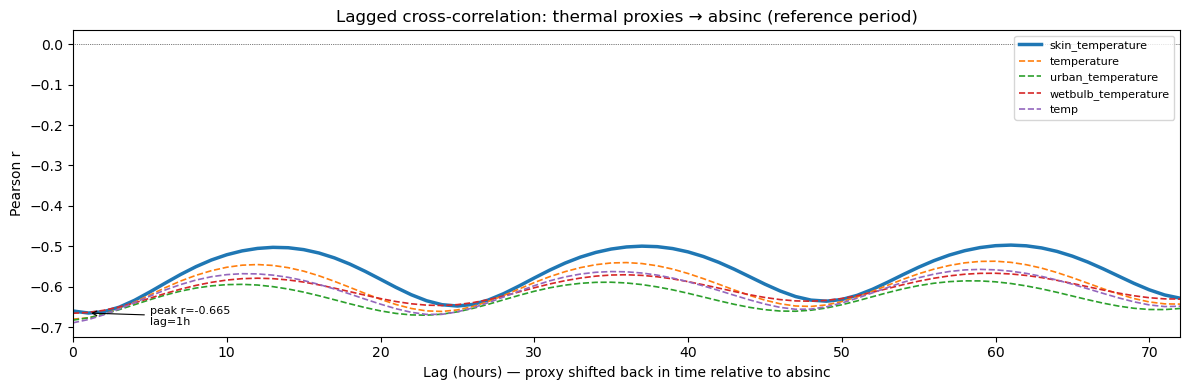

In [24]:
TOP_PROXIES = [
    "oikolab_skin_temperature (degC)",
    "oikolab_temperature (degC)",
    "oikolab_urban_temperature (degC)",
    "oikolab_wetbulb_temperature (degC)",
    "temp",
]

fig, ax = plt.subplots(figsize=(12, 4))

for col in TOP_PROXIES:
    lags, corrs = [], []
    for lag in range(0, MAX_LAG_H + 1, LAG_STEP):
        shifted = ref[col].shift(lag)
        valid   = pd.concat([ref[TARGET], shifted], axis=1).dropna()
        r, _    = pearsonr(valid.iloc[:, 0], valid.iloc[:, 1])
        lags.append(lag)
        corrs.append(r)
    
    # highlight skin temperature
    lw    = 2.5 if col == "oikolab_skin_temperature (degC)" else 1.2
    ls    = "-"  if col == "oikolab_skin_temperature (degC)" else "--"
    label = col.replace("oikolab_", "").replace(" (degC)", "").replace(" (W/m^2)", "")
    ax.plot(lags, corrs, lw=lw, ls=ls, label=label)

# annotate peak for skin temperature
skin_corrs = [pearsonr(
    pd.concat([ref[TARGET], ref["oikolab_skin_temperature (degC)"].shift(l)], axis=1).dropna().iloc[:, 0],
    pd.concat([ref[TARGET], ref["oikolab_skin_temperature (degC)"].shift(l)], axis=1).dropna().iloc[:, 1]
)[0] for l in range(0, MAX_LAG_H + 1)]
peak_lag  = int(np.argmax(np.abs(skin_corrs)))
peak_r    = skin_corrs[peak_lag]
ax.annotate(f"peak r={peak_r:.3f}\nlag={peak_lag}h",
            xy=(peak_lag, peak_r),
            xytext=(peak_lag + 4, peak_r - 0.03),
            fontsize=8,
            arrowprops=dict(arrowstyle="->", lw=0.8))

ax.axhline(0, color="black", lw=0.5, ls=":")
ax.set_xlabel("Lag (hours) — proxy shifted back in time relative to absinc")
ax.set_ylabel("Pearson r")
ax.set_title("Lagged cross-correlation: thermal proxies → absinc (reference period)")
ax.legend(fontsize=8, loc="upper right")
ax.set_xlim(0, MAX_LAG_H)
plt.tight_layout()
plt.savefig(f"{FIG_PATH}02_lag_crosscorr.png", dpi=150, bbox_inches="tight")
plt.show()